# Problem statement

 **house price prediction**

# Importing Libraries

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Importing dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Datasets/kc_house_data.csv")

# Summerize Dataset

In [6]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# Splitting dataset

In [11]:
x=df.iloc[:,3:]
y=df["price"]

# Transformation

In [13]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
x_transformed=scale.fit_transform(x)

In [12]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x_transformed,y,test_size=0.25,random_state=1)

# Creating model & Training

In [15]:
model=tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=50,input_shape=(18,),activation='relu'))
model.add(tf.keras.layers.Dense(units=50,activation='relu'))
model.add(tf.keras.layers.Dense(units=50,activation='relu'))
model.add(tf.keras.layers.Dense(units=1,activation='linear'))
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 50)                  │             950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,101 (23.83 KB)

 Trainable params: 6,101 (23.83 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss=tf.keras.losses.mae,optimizer='Adam')

In [19]:
epoch_hist=model.fit(x_train,y_train,epochs=100,batch_size=50,validation_split=0.2)


Epoch 1/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 531760.3125 - val_loss: 528974.8750
Epoch 2/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 493121.7812 - val_loss: 272156.8750
Epoch 3/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 214190.9062 - val_loss: 187257.6094
Epoch 4/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 178733.1094 - val_loss: 184218.2969
Epoch 5/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 179236.2188 - val_loss: 181027.0938
Epoch 6/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 176160.6250 - val_loss: 177466.0156
Epoch 7/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 169947.4219 - val_loss: 173672.3750
Epoch 8/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 165994.6875 - val_loss: 169581.6562
Epoch 9/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 159625.0781 - val_loss: 165186.0625
Epoch 10/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 161310.9375 - val_loss: 160474.5625
Epoch 11/100
260/260 ━━━━━━━━

In [22]:
print(epoch_hist.history.keys())

dict_keys(['loss', 'val_loss'])


# Plotting

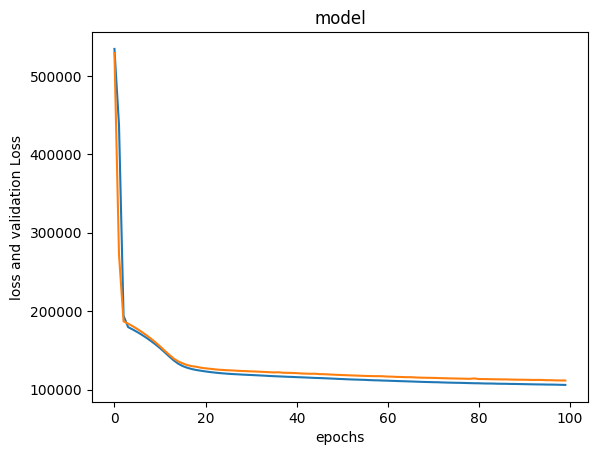

In [23]:
plt.plot(epoch_hist.history['loss'])
plt.plot(epoch_hist.history['val_loss'])
plt.title("model")
plt.xlabel("epochs")
plt.ylabel("loss and validation Loss")
plt.show()

# Evaluating

In [24]:
y_pred=model.predict(x_test)


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [25]:
from sklearn.metrics import r2_score,mean_squared_error

In [26]:
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.7118778372085783
46134522352.89499
